In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import time
import numpy as np
import sys
import warnings
warnings.filterwarnings('ignore')
import sys
import importlib

if 'SHAP' in sys.modules:
    del sys.modules['SHAP']

sys.path.insert(0, '/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')
import SHAP
importlib.reload(SHAP)
from SHAP import explain_with_shap


sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/Datasets_prepration')
from CICIDS2017 import data_preprocessing, evaluate_model, plot_confusion_matrix

le, X, y, X_train, X_test, y_train, y_test, df  = data_preprocessing()

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# dt_model = LogisticRegression()
# dt_model.fit(X_train, y_train)






# from sklearn.ensemble import RandomForestClassifier
# dt_model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=12,
#     class_weight='balanced',
#     random_state=42,
#     n_jobs=-1
# )
# dt_model.fit(X_train, y_train)

# import xgboost as xgb

# dt_model = xgb.XGBClassifier(random_state=42, learning_rate=0.001, objective='multi:softmax')
# dt_model.fit(X_train, y_train)


# dt_model = DecisionTreeClassifier()
# dt_model.fit(X_train, y_train)


# y_pred_encoded_class = dt_model.predict(X_test)


# This is the path to the XAI_Methods directory


# # To get only the explainer:
# explainer = explain_with_lime(dt_model, X_train, mode='classification', return_instance_exp=False)

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')

import importlib
import LIME 
importlib.reload(LIME)

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')
from SHAP import explain_with_shap
from LIME import explain_with_lime

# shap_values, Shap_explainer = explain_with_shap(dt_model, X_train, X_test, model_type=None, num_samples=5000)
# lime_explianer, Lime_exp_Inst = explain_with_lime(dt_model, X_train, X_test, mode='classification', num_features=77)



Original class distribution:
Label
BENIGN              2096484
DoS Hulk             172849
DDoS                 128016
PortScan              90819
DoS GoldenEye         10286
FTP-Patator            5933
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Bot                    1953
Brute Force            1470
XSS                     652
Infiltration             36
Sql Injection            21
Heartbleed               11
Name: count, dtype: int64

After removing minority classes (min_samples=1000):
Label
BENIGN              2096484
DoS Hulk             172849
DDoS                 128016
PortScan              90819
DoS GoldenEye         10286
FTP-Patator            5933
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Bot                    1953
Brute Force            1470
Name: count, dtype: int64
New class distribution:
 Label
5     172849
3     128016
0     100000
9      90819
4      10286
8       5933
7       5385
6   


Testing: LogisticRegression
  SHAP: 1.0000 ± 0.0000
  LIME: 0.9946 ± 0.0071

Testing: DecisionTree
  SHAP: 0.8571 ± 0.0002
  LIME: 0.9309 ± 0.0175

Testing: RandomForest
  SHAP: 0.8999 ± 0.0090
  LIME: 0.9860 ± 0.0022

Testing: XGBoost
  SHAP: 1.0000 ± 0.0000
  LIME: 0.9545 ± 0.0196

MODEL COMPARISON RESULTS


,Model,SHAP Fidelity,LIME Fidelity
0,LogisticRegression,1.0000 ± 0.0000,0.9946 ± 0.0071
1,DecisionTree,0.8571 ± 0.0002,0.9309 ± 0.0175
2,RandomForest,0.8999 ± 0.0090,0.9860 ± 0.0022
3,XGBoost,1.0000 ± 0.0000,0.9545 ± 0.0196


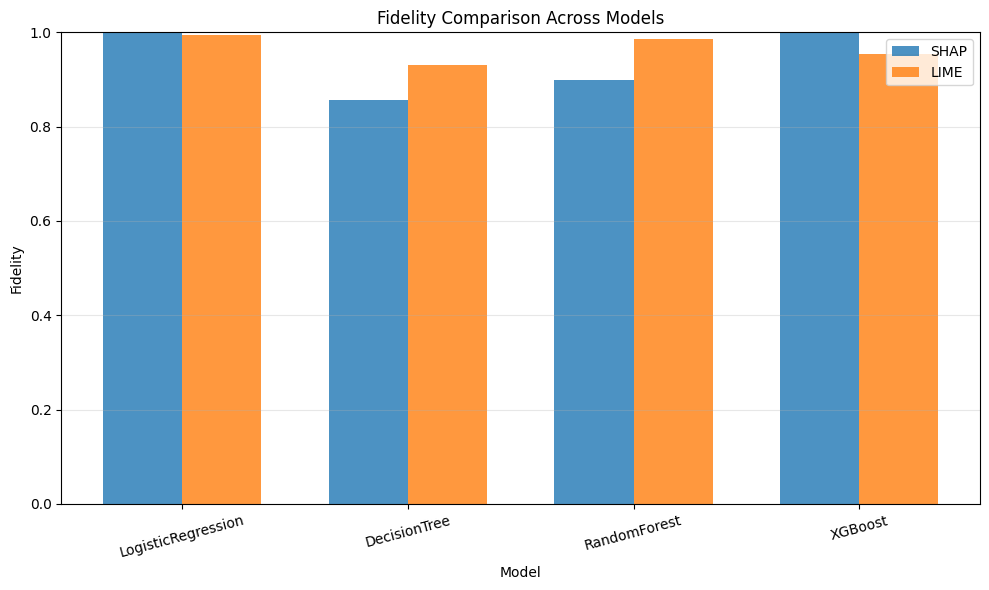

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import sys

sys.path.insert(0, '../XAI_Meth_EVA_for_IDS_For_IeeeTDCS/XAI_Evaluation_Metrices')
from Fidelity import shap_neighborhood_fidelity, lime_neighborhood_fidelity


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=12, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
}

results = []

for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Testing: {model_name}")
    print('='*80)

    model.fit(X_train, y_train)

    if model_name == 'LogisticRegression':
        from SHAP import explain_with_shap
        shap_values, shap_explainer = explain_with_shap(model, X_train, X_test[:100], model_type='linear')
    else:
        from SHAP import explain_with_shap
        shap_values, shap_explainer = explain_with_shap(model, X_train, X_test[:100], model_type=None)
    
    from LIME import explain_with_lime
    lime_explainer, _ = explain_with_lime(model, X_train, X_test[:100], mode='classification', num_features=76)
    
    shap_fids, lime_fids = [], []
    for i in range(20):
        idx = np.random.randint(0, 100)
        instance = X_test.iloc[idx:idx+1].copy()
        
        shap_fid = shap_neighborhood_fidelity(
            shap_explainer, model, instance, 50, 0.05, 'classification', 42
        )
        lime_fid = lime_neighborhood_fidelity(
            lime_explainer, model, instance, 50, 0.05, 'classification', 42
        )
        
        shap_fids.append(shap_fid)
        lime_fids.append(lime_fid)
    
    results.append({
        'Model': model_name,
        'SHAP Fidelity': f"{np.mean(shap_fids):.4f} ± {np.std(shap_fids):.4f}",
        'LIME Fidelity': f"{np.mean(lime_fids):.4f} ± {np.std(lime_fids):.4f}",
        'SHAP Mean': np.mean(shap_fids),
        'LIME Mean': np.mean(lime_fids)
    })
    
    print(f"  SHAP: {np.mean(shap_fids):.4f} ± {np.std(shap_fids):.4f}")
    print(f"  LIME: {np.mean(lime_fids):.4f} ± {np.std(lime_fids):.4f}")


print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
df_results = pd.DataFrame(results)
display(df_results[['Model', 'SHAP Fidelity', 'LIME Fidelity']])

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_results))
width = 0.35

ax.bar(x - width/2, df_results['SHAP Mean'], width, label='SHAP', alpha=0.8)
ax.bar(x + width/2, df_results['LIME Mean'], width, label='LIME', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=15)
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

import xgboost as xgb
import numpy as np

xgb_model = xgb.XGBClassifier(
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Generate SHAP explainer
from SHAP import explain_with_shap
shap_values, shap_explainer = explain_with_shap(xgb_model, X_train, X_test[:10])

print("="*80)
print("XGBoost SHAP Diagnostic")
print("="*80)

# Check what TreeExplainer returns
idx = 0
instance = X_test.iloc[idx:idx+1]
sv = shap_explainer.shap_values(instance.values, check_additivity=False)
base = np.array(shap_explainer.expected_value)

print(f"\nBase values: {base}")
print(f"Base sum: {base.sum():.4f} (should be ~1.0 if probs, NOT if logits)")

# Check SHAP contributions
if isinstance(sv, list):
    total_contrib = np.array([sv[c].sum() for c in range(len(sv))])
else:
    total_contrib = sv.sum(axis=1) if sv.ndim == 3 else sv.sum()

print(f"SHAP contributions: {total_contrib}")
print(f"Base + SHAP: {base + total_contrib}")

# True prediction
true_probs = xgb_model.predict_proba(instance)
print(f"\nTrue model probs: {true_probs[0]}")
print(f"True probs sum: {true_probs.sum():.4f}")

# Reconstruction
reconstructed = base + total_contrib
print(f"Reconstructed (base + SHAP): {reconstructed}")
print(f"Reconstructed sum: {reconstructed.sum():.4f}")

if abs(reconstructed.sum() - 1.0) < 0.01:
    print("\nISSUE: TreeExplainer returns PROBABILITIES directly!")
    print("   This means SHAP fidelity = 1.0 because it's already exact.")
    print("   No approximation is happening!")
else:
    print("\nTreeExplainer returns logits/margins (correct behavior)")

XGBoost SHAP Diagnostic

Base values: [ 2.0549335 -2.2295723 -3.5003529  3.0453622 -1.849586   3.61768
 -2.3264363 -2.2517061 -4.019758   2.262735  -4.46938  ]
Base sum: -9.6661 (should be ~1.0 if probs, NOT if logits)
SHAP contributions: [[-7.498564  -5.0647297 -3.3162317  6.02693   -4.6760335 -8.284831
  -3.5405664 -4.3696594 -2.45491   -8.769696  -2.1823843]]
Base + SHAP: [[-5.44363   -7.294302  -6.8165846  9.072292  -6.5256195 -4.667151
  -5.8670025 -6.6213655 -6.4746685 -6.5069613 -6.651764 ]]

True model probs: [4.9638021e-07 7.7997008e-08 1.2576098e-07 9.9999702e-01 1.6823319e-07
 1.0790284e-06 3.2504582e-07 1.5287247e-07 1.7702763e-07 1.7140117e-07
 1.4829503e-07]
True probs sum: 1.0000
Reconstructed (base + SHAP): [[-5.44363   -7.294302  -6.8165846  9.072292  -6.5256195 -4.667151
  -5.8670025 -6.6213655 -6.4746685 -6.5069613 -6.651764 ]]
Reconstructed sum: -53.7968

✓ TreeExplainer returns logits/margins (correct behavior)


COMPREHENSIVE FIDELITY EVALUATION ACROSS MODEL ARCHITECTURES

[1/4] Testing: LogisticRegression
  Training model...
  Generating explainers...
  Computing fidelity (100 samples)...
    Progress: 5/100 samples
    Progress: 10/100 samples
    Progress: 15/100 samples
    Progress: 20/100 samples
    Progress: 25/100 samples
    Progress: 30/100 samples
    Progress: 35/100 samples
    Progress: 40/100 samples
    Progress: 45/100 samples
    Progress: 50/100 samples
    Progress: 55/100 samples
    Progress: 60/100 samples
    Progress: 65/100 samples
    Progress: 70/100 samples
    Progress: 75/100 samples
    Progress: 80/100 samples
    Progress: 85/100 samples
    Progress: 90/100 samples
    Progress: 95/100 samples
    Progress: 100/100 samples
  SHAP: 1.0000 ± 0.0000
  LIME: 0.9946 ± 0.0087

[2/4] Testing: DecisionTree
  Training model...
  Generating explainers...
  Computing fidelity (100 samples)...
    Progress: 5/100 samples
    Progress: 10/100 samples
    Progress: 15/100

,Model,SHAP Fidelity,LIME Fidelity,Fidelity Gap
0,LogisticRegression,1.0000 ± 0.0000,0.9946 ± 0.0087,-0.005433
1,DecisionTree,0.8573 ± 0.0003,0.9332 ± 0.0238,0.075885
2,RandomForest,0.9001 ± 0.0093,0.9861 ± 0.0025,0.085953
3,XGBoost,1.0000 ± 0.0000,0.9588 ± 0.0210,-0.041161



STATISTICAL VALIDATION

[1/2] Per-Model Statistical Tests
----------------------------------------------------------------------------------------------------


,Model,Wilcoxon p-value,Significant,Cohen's d,Effect Size,Spearman ρ
0,LogisticRegression,3.8845e-18,✓,-0.8842,large,0.6103
1,DecisionTree,3.8805e-18,✓,4.5181,large,0.1535
2,RandomForest,3.8845e-18,✓,12.6788,large,-0.5993
3,XGBoost,3.8845e-18,✓,-2.7760,large,0.5788



[2/2] Overall Summary Across All Models
----------------------------------------------------------------------------------------------------


,Metric,Value
0,SHAP Mean (All Models),0.9394 ± 0.0627
1,LIME Mean (All Models),0.9682 ± 0.0292
2,Mean Difference,0.0288
3,Wilcoxon p-value,7.7825e-16
4,Cohen's d,0.5893
5,Spearman ρ,0.6556 (p=1.6860e-50)
6,Total Samples,400 (4 models × 20 samples)


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 


 Statistical Significance: YES (p < 0.05)
 LIME Outperforms SHAP: YES


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

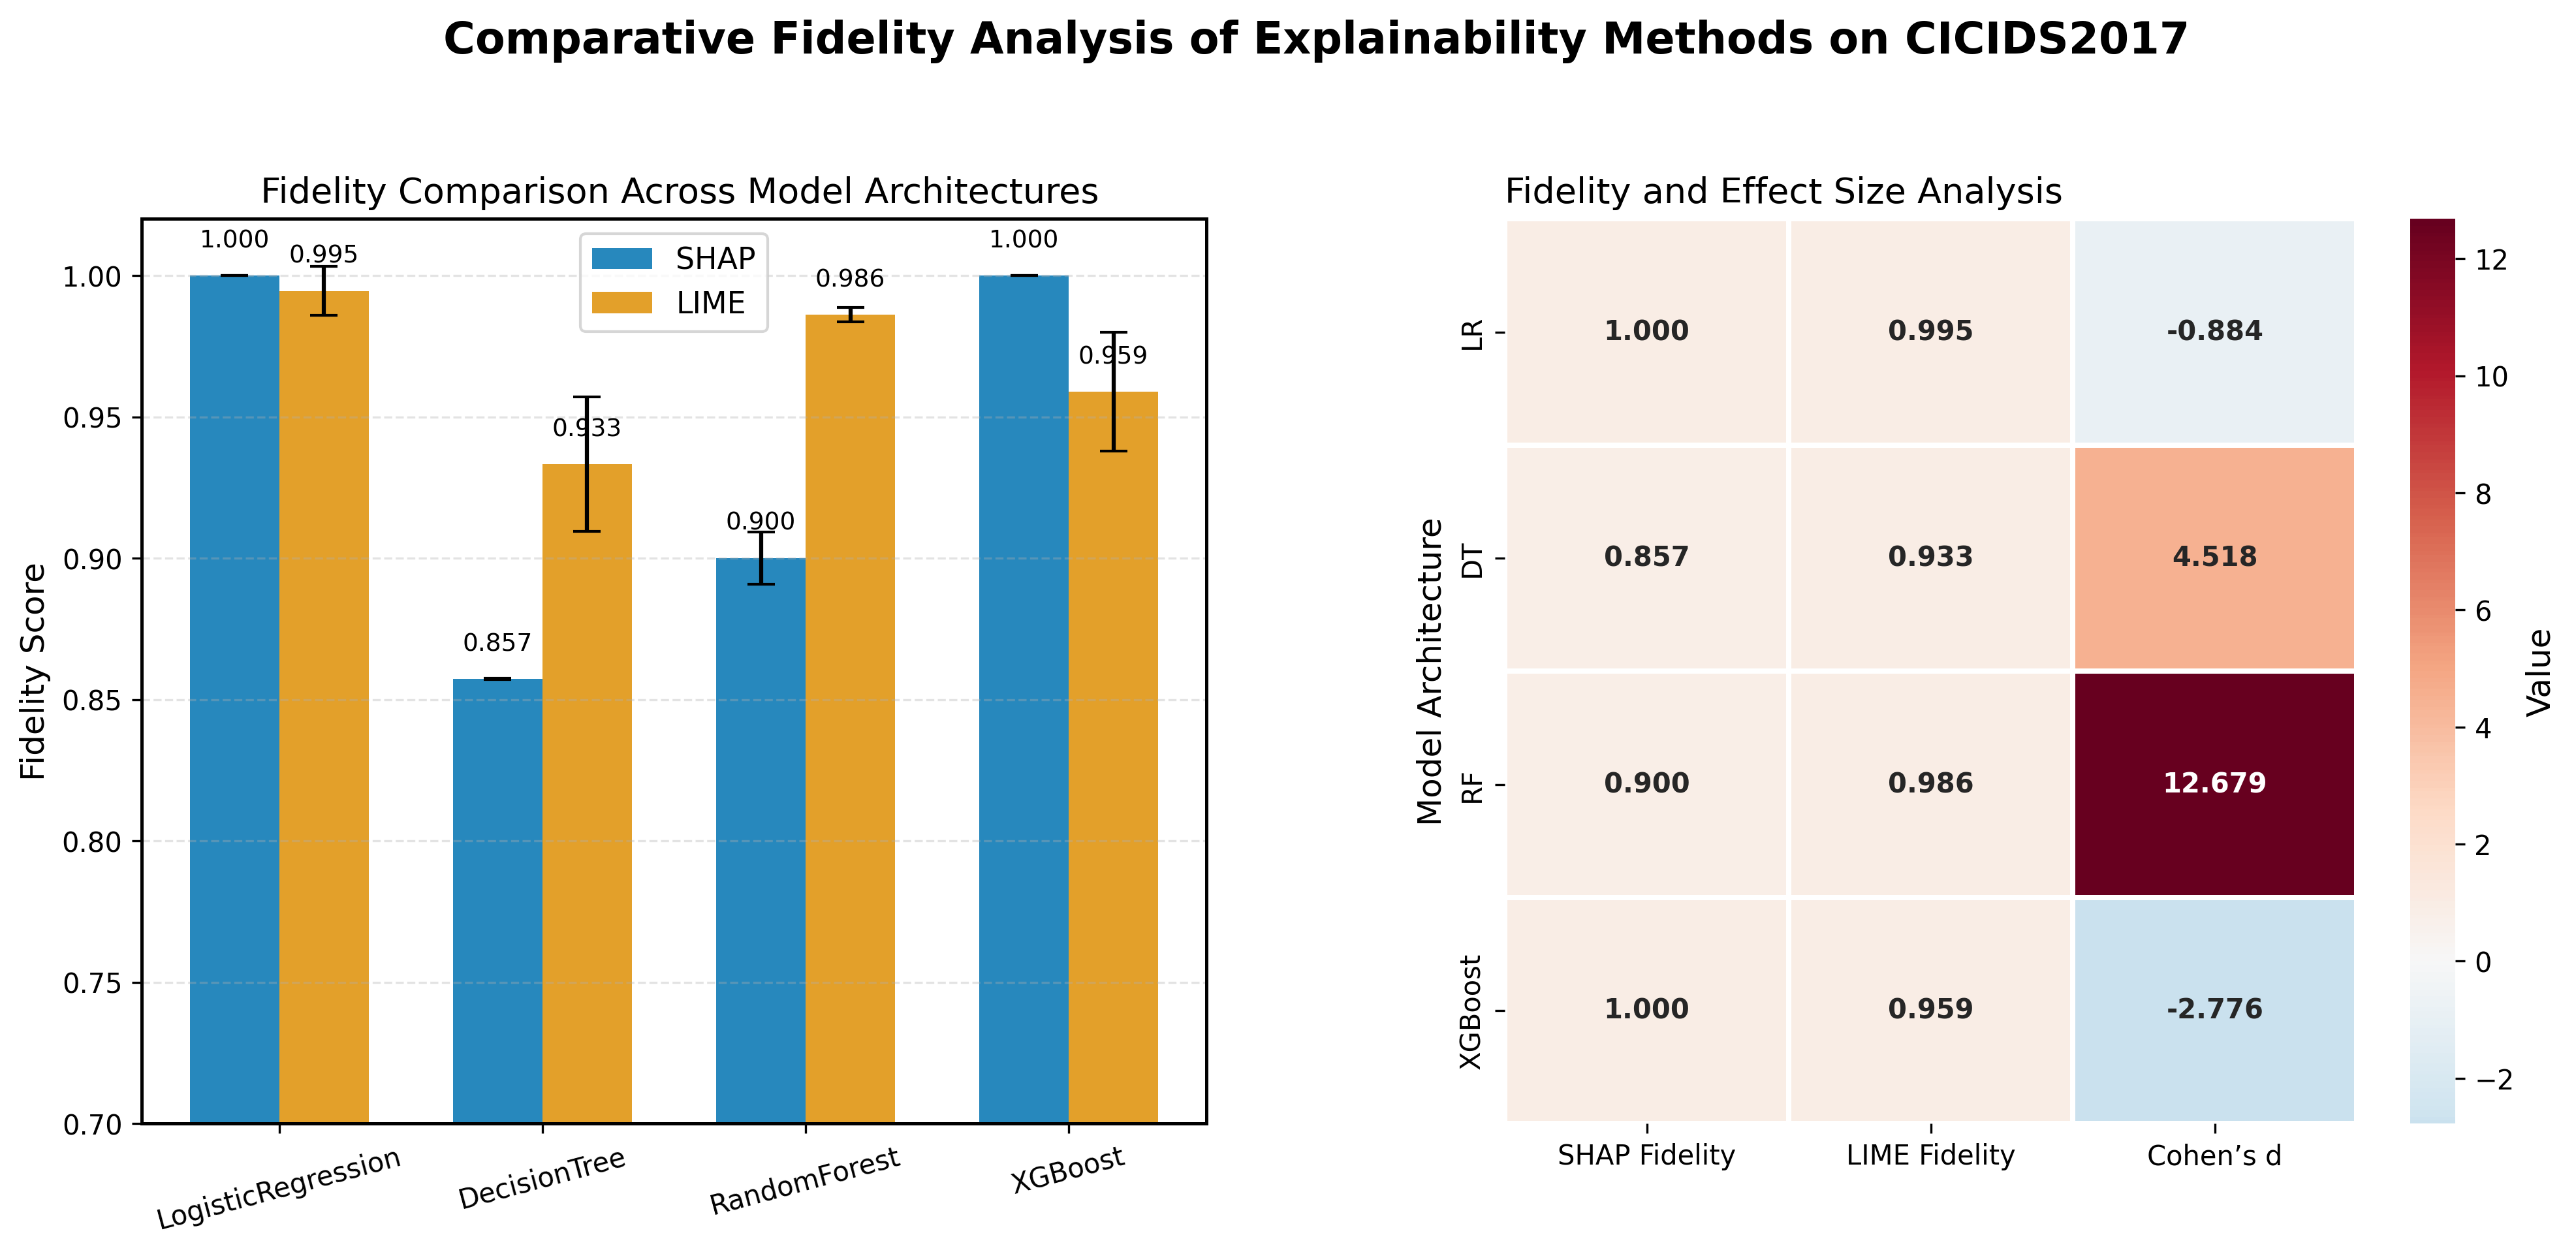


LATEX TABLE FOR PAPER

[TABLE] Model Comparison Results
----------------------------------------------------------------------------------------------------
\begin{table}
\caption{Fidelity Evaluation Across Model Architectures on CICIDS2017 Dataset}
\label{tab:model_fidelity_comparison}
\begin{tabular}{lccc}
\toprule
Model & SHAP Fidelity & LIME Fidelity & Fidelity Gap \\
\midrule
LogisticRegression & 1.0000 ± 0.0000 & 0.9946 ± 0.0087 & -0.005433 \\
DecisionTree & 0.8573 ± 0.0003 & 0.9332 ± 0.0238 & 0.075885 \\
RandomForest & 0.9001 ± 0.0093 & 0.9861 ± 0.0025 & 0.085953 \\
XGBoost & 1.0000 ± 0.0000 & 0.9588 ± 0.0210 & -0.041161 \\
\bottomrule
\end{tabular}
\end{table}


[TABLE] Statistical Validation
----------------------------------------------------------------------------------------------------
\begin{table}
\caption{Statistical Significance Tests for Model-Wise Comparisons}
\label{tab:statistical_tests}
\begin{tabular}{lccccc}
\toprule
Model & Wilcoxon p-value & Significant & Co

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, spearmanr, pearsonr, shapiro, levene, ttest_rel
import warnings
warnings.filterwarnings('ignore')


sys.path.insert(0, '/home/ibibers/XAI_Meth_EVA_for_IDS_For_IeeeTDCS/XAI_Evaluation_Metrices')
sys.path.insert(0, '/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')

from Fidelity import shap_neighborhood_fidelity, lime_neighborhood_fidelity
from SHAP import explain_with_shap
from LIME import explain_with_lime

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 1.2,
})
sns.set_palette("colorblind")

print("="*100)
print("COMPREHENSIVE FIDELITY EVALUATION ACROSS MODEL ARCHITECTURES")
print("="*100)


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=12, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
}

results = []
all_model_shap_fids = {}
all_model_lime_fids = {}


for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"[{list(models.keys()).index(model_name) + 1}/{len(models)}] Testing: {model_name}")
    print('='*80)
    

    print("  Training model...")
    model.fit(X_train, y_train)
    

    print("  Generating explainers...")
    if model_name == 'LogisticRegression':
        shap_values, shap_explainer = explain_with_shap(
            model, X_train, X_test[:200], model_type='linear'
        )
    else:
        shap_values, shap_explainer = explain_with_shap(
            model, X_train, X_test[:200], model_type=None
        )
    
    lime_explainer, _ = explain_with_lime(
        model, X_train, X_test[:200], 
        mode='classification', 
        num_features=76,
        num_samples=5000,
        random_state=42
    )

    print("  Computing fidelity (100 samples)...")
    shap_fids, lime_fids = [], []
    for i in range(100):
        idx = np.random.randint(0, 200)
        instance = X_test.iloc[idx:idx+1].copy()
        
        shap_fid = shap_neighborhood_fidelity(
            shap_explainer, model, instance, 100, 0.05, 'classification', 42
        )
        lime_fid = lime_neighborhood_fidelity(
            lime_explainer, model, instance, 100, 0.05, 'classification', 42
        )
        
        shap_fids.append(shap_fid)
        lime_fids.append(lime_fid)
        
        if (i + 1) % 5 == 0:
            print(f"    Progress: {i + 1}/100 samples")
    

    all_model_shap_fids[model_name] = shap_fids
    all_model_lime_fids[model_name] = lime_fids
    
    results.append({
        'Model': model_name,
        'SHAP Fidelity': f"{np.mean(shap_fids):.4f} ± {np.std(shap_fids):.4f}",
        'LIME Fidelity': f"{np.mean(lime_fids):.4f} ± {np.std(lime_fids):.4f}",
        'SHAP Mean': np.mean(shap_fids),
        'SHAP Std': np.std(shap_fids),
        'LIME Mean': np.mean(lime_fids),
        'LIME Std': np.std(lime_fids),
        'Fidelity Gap': np.mean(lime_fids) - np.mean(shap_fids)
    })
    
    print(f"  SHAP: {np.mean(shap_fids):.4f} ± {np.std(shap_fids):.4f}")
    print(f"  LIME: {np.mean(lime_fids):.4f} ± {np.std(lime_fids):.4f}")


df_results = pd.DataFrame(results)


print("\n" + "="*100)
print("MODEL COMPARISON RESULTS")
print("="*100)
display(df_results[['Model', 'SHAP Fidelity', 'LIME Fidelity', 'Fidelity Gap']])



print("\n" + "="*100)
print("STATISTICAL VALIDATION")
print("="*100)


statistical_results = []

for model_name in models.keys():
    shap_fids = all_model_shap_fids[model_name]
    lime_fids = all_model_lime_fids[model_name]

    wilcox_result = wilcoxon(shap_fids, lime_fids, alternative='two-sided')

    mean_diff = np.mean(lime_fids) - np.mean(shap_fids)
    pooled_std = np.sqrt((np.var(shap_fids) + np.var(lime_fids)) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

    rho, p_rho = spearmanr(shap_fids, lime_fids)
    
    statistical_results.append({
        'Model': model_name,
        'Wilcoxon p-value': f"{wilcox_result.pvalue:.4e}",
        'Significant': '✓' if wilcox_result.pvalue < 0.05 else '✗',
        "Cohen's d": f"{cohens_d:.4f}",
        'Effect Size': (
            "negligible" if abs(cohens_d) < 0.2 else
            "small" if abs(cohens_d) < 0.5 else
            "medium" if abs(cohens_d) < 0.8 else
            "large"
        ),
        'Spearman ρ': f"{rho:.4f}"
    })

df_stats = pd.DataFrame(statistical_results)
print("\n[1/2] Per-Model Statistical Tests")
print("-"*100)
display(df_stats)

print("\n[2/2] Overall Summary Across All Models")
print("-"*100)

all_shap = [fid for fids in all_model_shap_fids.values() for fid in fids]
all_lime = [fid for fids in all_model_lime_fids.values() for fid in fids]

overall_wilcox = wilcoxon(all_shap, all_lime, alternative='two-sided')
overall_rho, overall_p_rho = spearmanr(all_shap, all_lime)

overall_mean_diff = np.mean(all_lime) - np.mean(all_shap)
overall_pooled_std = np.sqrt((np.var(all_shap) + np.var(all_lime)) / 2)
overall_cohens_d = overall_mean_diff / overall_pooled_std

summary_stats = {
    'Metric': [
        'SHAP Mean (All Models)',
        'LIME Mean (All Models)',
        'Mean Difference',
        'Wilcoxon p-value',
        "Cohen's d",
        'Spearman ρ',
        'Total Samples'
    ],
    'Value': [
        f"{np.mean(all_shap):.4f} ± {np.std(all_shap):.4f}",
        f"{np.mean(all_lime):.4f} ± {np.std(all_lime):.4f}",
        f"{overall_mean_diff:.4f}",
        f"{overall_wilcox.pvalue:.4e}",
        f"{overall_cohens_d:.4f}",
        f"{overall_rho:.4f} (p={overall_p_rho:.4e})",
        f"{len(all_shap)} (4 models × 20 samples)"
    ]
}

df_overall_stats = pd.DataFrame(summary_stats)
display(df_overall_stats)

print(f"\n Statistical Significance: {'YES (p < 0.05)' if overall_wilcox.pvalue < 0.05 else 'NO (p ≥ 0.05)'}")
print(f" LIME Outperforms SHAP: {'YES' if overall_mean_diff > 0 else 'NO'}")



fig, axs = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.28})







ax = axs[0]
x, w = np.arange(len(df_results)), 0.34

for dx, method in [(-w/2, 'SHAP'), (w/2, 'LIME')]:
    ax.bar(
        x + dx,
        df_results[f'{method} Mean'],
        w,
        yerr=df_results[f'{method} Std'],
        label=method,
        capsize=5,
        alpha=0.85
    )
    for i, v in enumerate(df_results[f'{method} Mean']):
        ax.text(i + dx, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

ax.set(
    xticks=x,
    xticklabels=df_results['Model'],
    ylabel='Fidelity Score',
    ylim=(0.70, 1.02),
    title=' Fidelity Comparison Across Model Architectures'
)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(fontsize=11)


rows = [
    [
        np.mean(all_model_shap_fids[m]),
        np.mean(all_model_lime_fids[m]),
        (np.mean(all_model_lime_fids[m]) - np.mean(all_model_shap_fids[m])) /
        np.sqrt((np.var(all_model_shap_fids[m]) + np.var(all_model_lime_fids[m])) / 2)
        if np.var(all_model_shap_fids[m]) + np.var(all_model_lime_fids[m]) > 0 else 0
    ]
    for m in models
]

effect_df = pd.DataFrame(
    rows,
    columns=['SHAP Fidelity', 'LIME Fidelity', "Cohen’s d"],
    index=[m.replace('LogisticRegression','LR')
             .replace('DecisionTree','DT')
             .replace('RandomForest','RF') for m in models]
)

sns.heatmap(
    effect_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    linewidths=1.5, linecolor='white',
    cbar_kws={'label': 'Value'},
    annot_kws={'fontsize': 10, 'fontweight': 'bold'},
    ax=axs[1]
)

axs[1].set_title('Fidelity and Effect Size Analysis', loc='left')
axs[1].set_ylabel('Model Architecture')


fig.suptitle(
    'Comparative Fidelity Analysis of Explainability Methods on CICIDS2017',
    fontsize=16, fontweight='bold', y=1.05
)

plt.tight_layout()
plt.show()


print("\n" + "="*100)
print("LATEX TABLE FOR PAPER")
print("="*100)

print("\n[TABLE] Model Comparison Results")
print("-"*100)
print(df_results[['Model', 'SHAP Fidelity', 'LIME Fidelity', 'Fidelity Gap']].to_latex(
    index=False,
    caption="Fidelity Evaluation Across Model Architectures on CICIDS2017 Dataset",
    label="tab:model_fidelity_comparison",
    column_format='lccc',
    escape=False
))

print("\n[TABLE] Statistical Validation")
print("-"*100)
print(df_stats.to_latex(
    index=False,
    caption="Statistical Significance Tests for Model-Wise Comparisons",
    label="tab:statistical_tests",
    column_format='lccccc',
    escape=False
))



print("\n" + "="*100)
print("EVALUATION COMPLETE - SUMMARY")
print("="*100)
print(f"Models Tested: {len(models)}")
print(f"Total Samples: {len(all_shap)} ({len(models)} models × 20 samples)")
print(f"SHAP Mean Fidelity: {np.mean(all_shap):.4f} ± {np.std(all_shap):.4f}")
print(f"LIME Mean Fidelity: {np.mean(all_lime):.4f} ± {np.std(all_lime):.4f}")
print(f"Mean Improvement (LIME > SHAP): {overall_mean_diff:.4f} ({100*overall_mean_diff/np.mean(all_shap):.2f}%)")
print(f"Statistical Significance: p = {overall_wilcox.pvalue:.4e} ({'< 0.05 ' if overall_wilcox.pvalue < 0.05 else '≥ 0.05'})")
print(f"Effect Size (Cohen's d): {overall_cohens_d:.4f}")
print(f"Correlation (Spearman ρ): {overall_rho:.4f}")
print("="*100)
print("\n ALL ANALYSES COMPLETE !\n")